In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

import mlflow

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

print(f"SHAP version: {shap.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print("Imports successful.")

SHAP version: 0.51.0
XGBoost version: 3.2.0
Imports successful.


In [2]:
# Cell 2 — Load processed data and rebuild tuned XGBoost
# We're rebuilding rather than loading from MLflow because reproducibility 
# is easier when the recruiter can clone, run, and verify the result themselves.

X_train = pd.read_csv('../data/processed/X_train_tree.csv')
X_test = pd.read_csv('../data/processed/X_test_tree.csv')
y_train = pd.read_csv('../data/processed/y_train_tree.csv')['target']
y_test = pd.read_csv('../data/processed/y_test.csv')['target_binary']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Re-tune XGBoost (this takes 2-3 min — same as yesterday)
# Note: n_jobs=1 on the inner estimator to avoid the Windows access violations 
# we hit yesterday with nested parallelism.
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1   # ← single-thread the inner XGBoost
    ),
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Re-tuning XGBoost...")
xgb_search.fit(X_train, y_train)

xgb_model = xgb_search.best_estimator_

print(f"\nBest CV ROC-AUC: {xgb_search.best_score_:.4f}")
print(f"\nTest set predictions:")
test_pred = xgb_model.predict(X_test)
test_proba = xgb_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score
print(f"  Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"  Recall:   {recall_score(y_test, test_pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, test_proba):.4f}")

Train: (262, 13), Test: (61, 13)
Re-tuning XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV ROC-AUC: 0.8868

Test set predictions:
  Accuracy: 0.8852
  Recall:   0.9286
  ROC-AUC:  0.9502


In [3]:
# Cell 3 — Initialize SHAP TreeExplainer on tuned XGBoost
# TreeExplainer: fast, exact, and the right choice for tree-based models.

explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the test set
# Output is an Explanation object containing values, base_values, and data
shap_values = explainer(X_test)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"  → 61 patients × 13 features = one SHAP value per (patient, feature) pair")
print(f"\nBase value (model's average prediction in log-odds): {explainer.expected_value:.4f}")
print(f"  → This is the baseline. SHAP values explain departures from this baseline.")
print(f"\nFirst patient's predicted probability: {xgb_model.predict_proba(X_test)[:1][:, 1][0]:.4f}")
print(f"First patient's SHAP values (one per feature):")
for feat, val in zip(X_test.columns, shap_values.values[0]):
    sign = '+' if val >= 0 else ''
    print(f"  {feat:12s}: {sign}{val:.4f}")

SHAP values shape: (61, 13)
  → 61 patients × 13 features = one SHAP value per (patient, feature) pair

Base value (model's average prediction in log-odds): 0.0025
  → This is the baseline. SHAP values explain departures from this baseline.

First patient's predicted probability: 0.2400
First patient's SHAP values (one per feature):
  age         : +0.1167
  trestbps    : +0.0000
  chol        : +0.0478
  thalach     : -0.2255
  oldpeak     : -0.1893
  sex         : +0.1399
  cp          : +0.5619
  fbs         : +0.0000
  restecg     : +0.0208
  exang       : -0.1532
  slope       : -0.2070
  ca          : -0.6551
  thal        : -0.6125


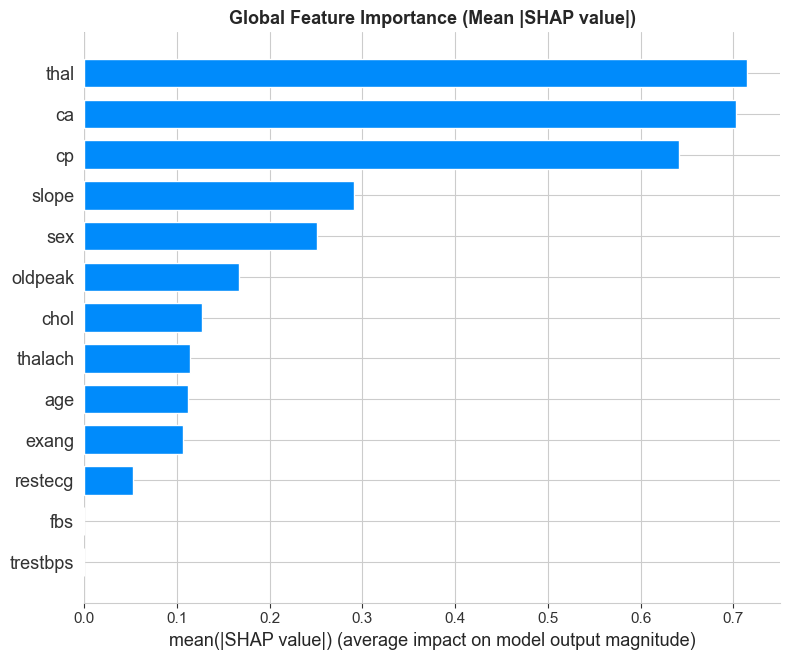

Saved: reports/figures/shap_global_bar.png


In [4]:
# Cell 4 — Global SHAP feature importance (bar plot)
# Mean absolute SHAP value across all 61 test patients = global feature importance.

os.makedirs('../reports/figures', exist_ok=True)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance (Mean |SHAP value|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_global_bar.png', dpi=120, bbox_inches='tight')
plt.show()

print("Saved: reports/figures/shap_global_bar.png")

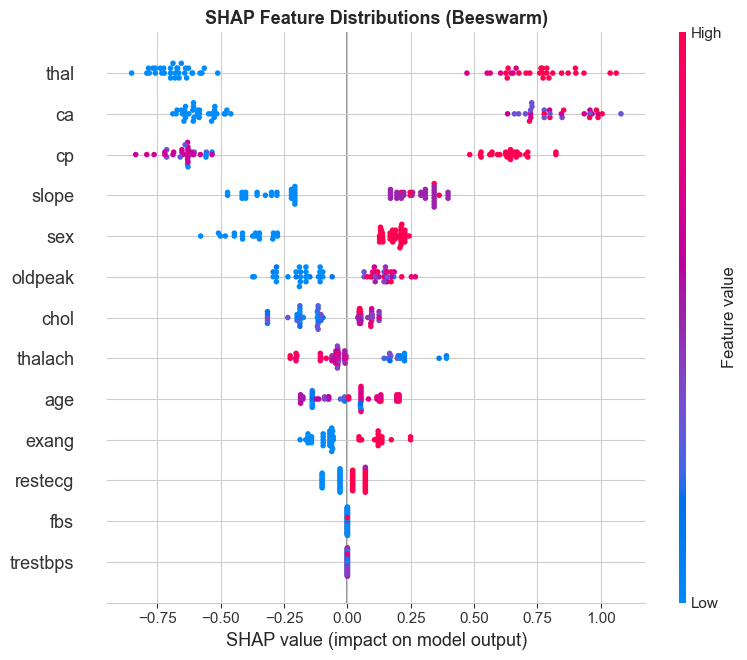

Saved: reports/figures/shap_beeswarm.png


In [5]:
# Cell 5 — Global SHAP beeswarm
# Each dot = one patient. Color = feature value (red=high, blue=low). 
# X-axis = SHAP value (push toward disease).
# Tells you not just which features matter, but HOW each value level pushes prediction.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='dot',  # default beeswarm
    show=False
)
plt.title('SHAP Feature Distributions (Beeswarm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

print("Saved: reports/figures/shap_beeswarm.png")

Most-healthy prediction: patient #59, probability = 0.0555, true label = 0
Most-disease prediction: patient #51, probability = 0.9626, true label = 1

=== Most-healthy patient: waterfall ===


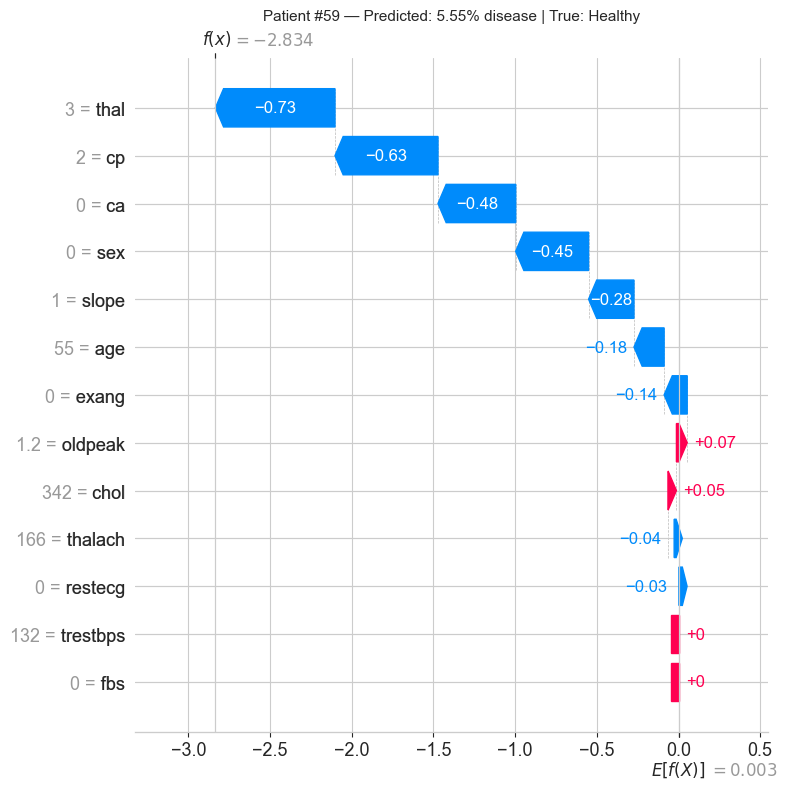


=== Most-disease patient: waterfall ===


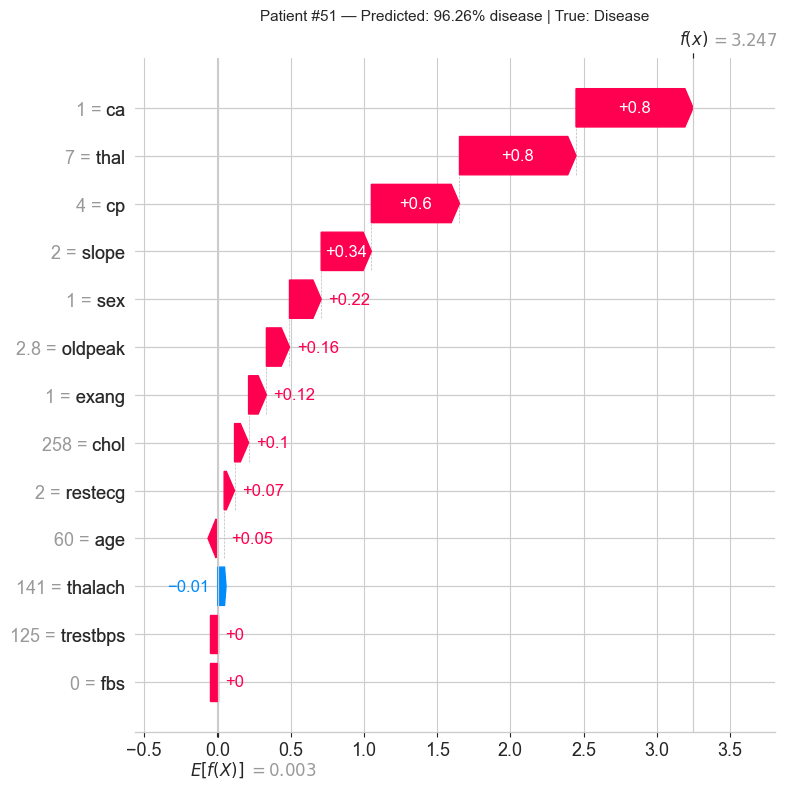


Saved both waterfall plots to reports/figures/


In [6]:
# Cell 6 — Per-patient force plots (waterfall view)
# Two patients: one the model confidently predicts as healthy, 
# one as disease. Show how features push prediction in each case.

import shap

# Find the test patients with the most extreme predictions
test_proba = xgb_model.predict_proba(X_test)[:, 1]

most_healthy_idx = np.argmin(test_proba)
most_disease_idx = np.argmax(test_proba)

print(f"Most-healthy prediction: patient #{most_healthy_idx}, probability = {test_proba[most_healthy_idx]:.4f}, true label = {y_test.iloc[most_healthy_idx]}")
print(f"Most-disease prediction: patient #{most_disease_idx}, probability = {test_proba[most_disease_idx]:.4f}, true label = {y_test.iloc[most_disease_idx]}")

# Waterfall plot for the most-healthy patient
print("\n=== Most-healthy patient: waterfall ===")
plt.figure()
shap.plots.waterfall(shap_values[most_healthy_idx], max_display=14, show=False)
plt.title(f'Patient #{most_healthy_idx} — Predicted: {test_proba[most_healthy_idx]:.2%} disease | True: {"Disease" if y_test.iloc[most_healthy_idx]==1 else "Healthy"}', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_healthy.png', dpi=120, bbox_inches='tight')
plt.show()

# Waterfall plot for the most-disease patient
print("\n=== Most-disease patient: waterfall ===")
plt.figure()
shap.plots.waterfall(shap_values[most_disease_idx], max_display=14, show=False)
plt.title(f'Patient #{most_disease_idx} — Predicted: {test_proba[most_disease_idx]:.2%} disease | True: {"Disease" if y_test.iloc[most_disease_idx]==1 else "Healthy"}', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_disease.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nSaved both waterfall plots to reports/figures/")

In [7]:
# Cell 7 — Save model + SHAP explainer for deployment
# These will be loaded by the FastAPI service in Block 3.

os.makedirs('../models', exist_ok=True)

# Save the tuned XGBoost model (XGBoost native JSON format — cleaner than pickle)
xgb_model.save_model('../models/xgb_tuned.json')

# Save the SHAP explainer too
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Save feature names for FastAPI input validation
feature_names = list(X_train.columns)
with open('../models/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_names))

print("Saved to models/:")
for f in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f"  {f}  ({size:.1f} KB)")

Saved to models/:
  feature_names.txt  (0.1 KB)
  shap_explainer.pkl  (451.5 KB)
  xgb_tuned.json  (109.1 KB)


In [8]:
# Cell 8 — Brier score on the raw (uncalibrated) XGBoost
from sklearn.metrics import brier_score_loss

# Get probability predictions on test set
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

# Brier score
brier_raw = brier_score_loss(y_test, y_test_proba)

print(f"Brier score (raw XGBoost): {brier_raw:.4f}")
print(f"\nReference points:")
print(f"  Perfect calibration: 0.0000")
print(f"  Predict 0.5 always:  0.2500")
print(f"  Random predictions:  ~0.33")
print(f"  Your model:          {brier_raw:.4f}")

Brier score (raw XGBoost): 0.0922

Reference points:
  Perfect calibration: 0.0000
  Predict 0.5 always:  0.2500
  Random predictions:  ~0.33
  Your model:          0.0922


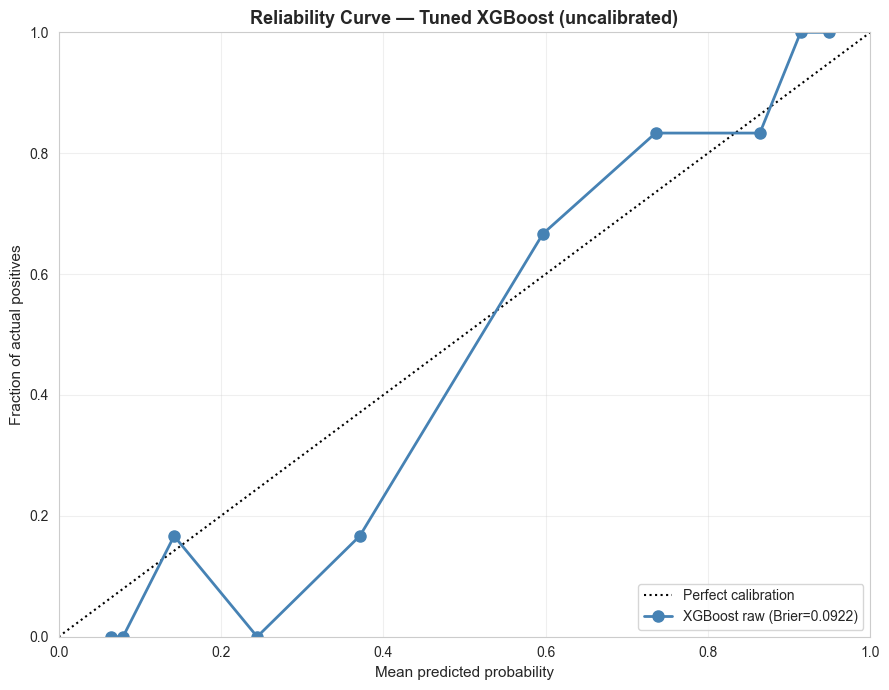

Predicted probability bins (mean): [0.064 0.079 0.142 0.245 0.371 0.597 0.735 0.864 0.914 0.949]
Actual positive fraction:          [0.    0.    0.167 0.    0.167 0.667 0.833 0.833 1.    1.   ]


In [9]:
# Cell 9 — Reliability curve (calibration plot)
from sklearn.calibration import calibration_curve

prob_true_raw, prob_pred_raw = calibration_curve(
    y_test, y_test_proba,
    n_bins=10,
    strategy='quantile'   # equal-frequency bins; better than 'uniform' on small datasets
)

plt.figure(figsize=(9, 7))
plt.plot([0, 1], [0, 1], 'k:', label='Perfect calibration', linewidth=1.5)
plt.plot(prob_pred_raw, prob_true_raw, 'o-', label=f'XGBoost raw (Brier={brier_raw:.4f})',
         color='steelblue', linewidth=2, markersize=8)

plt.xlabel('Mean predicted probability', fontsize=11)
plt.ylabel('Fraction of actual positives', fontsize=11)
plt.title('Reliability Curve — Tuned XGBoost (uncalibrated)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.savefig('../reports/figures/calibration_raw.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Predicted probability bins (mean): {prob_pred_raw.round(3)}")
print(f"Actual positive fraction:          {prob_true_raw.round(3)}")

In [10]:
# Cell 10 — Platt scaling via CalibratedClassifierCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

# Clone the tuned XGBoost so calibration doesn't mutate the original
xgb_for_calibration = clone(xgb_model)

# 5-fold CV on training data — fits a sigmoid (Platt) calibrator inside each fold
xgb_calibrated = CalibratedClassifierCV(
    xgb_for_calibration,
    method='sigmoid',   # Platt scaling
    cv=5,
    n_jobs=1            # avoid the Windows nested-parallelism issue
)

print("Fitting Platt-scaled XGBoost via 5-fold CV...")
xgb_calibrated.fit(X_train, y_train)
print("Done.")

# Evaluate calibrated model on test
y_test_proba_cal = xgb_calibrated.predict_proba(X_test)[:, 1]
brier_cal = brier_score_loss(y_test, y_test_proba_cal)

print(f"\nBrier score comparison:")
print(f"  Raw XGBoost:        {brier_raw:.4f}")
print(f"  Calibrated XGBoost: {brier_cal:.4f}")
print(f"  Improvement:        {brier_raw - brier_cal:+.4f}")

Fitting Platt-scaled XGBoost via 5-fold CV...
Done.

Brier score comparison:
  Raw XGBoost:        0.0922
  Calibrated XGBoost: 0.1037
  Improvement:        -0.0115


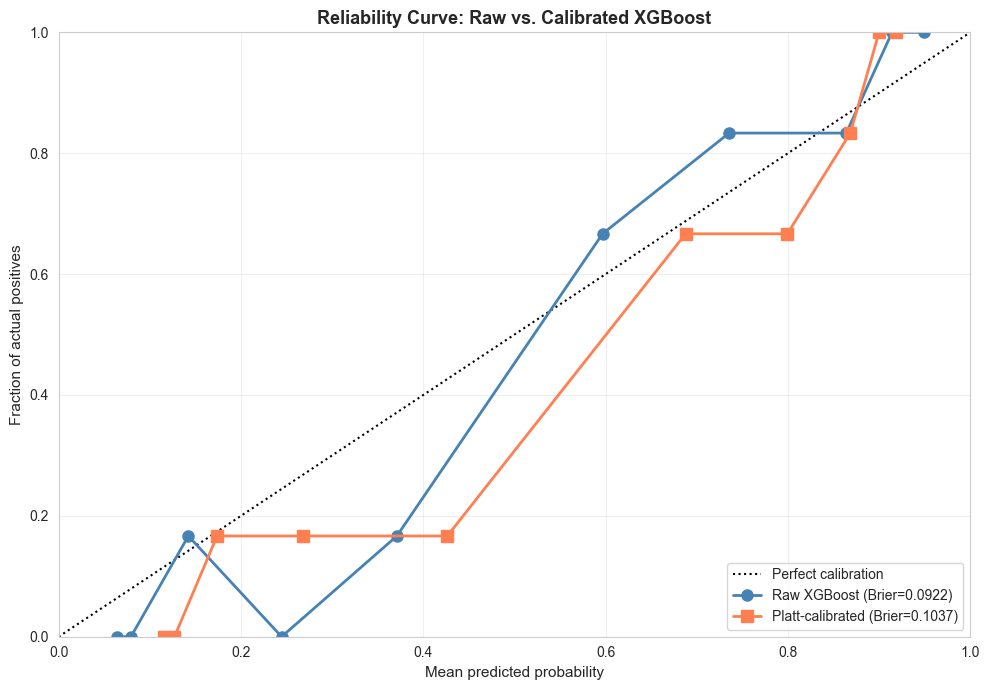

In [11]:
# Cell 11 — Side-by-side reliability curves
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, y_test_proba_cal,
    n_bins=10,
    strategy='quantile'
)

plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], 'k:', label='Perfect calibration', linewidth=1.5)

plt.plot(prob_pred_raw, prob_true_raw, 'o-',
         label=f'Raw XGBoost (Brier={brier_raw:.4f})',
         color='steelblue', linewidth=2, markersize=8)

plt.plot(prob_pred_cal, prob_true_cal, 's-',
         label=f'Platt-calibrated (Brier={brier_cal:.4f})',
         color='coral', linewidth=2, markersize=8)

plt.xlabel('Mean predicted probability', fontsize=11)
plt.ylabel('Fraction of actual positives', fontsize=11)
plt.title('Reliability Curve: Raw vs. Calibrated XGBoost', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.savefig('../reports/figures/calibration_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

THRESHOLD ANALYSIS (corrected)

Default threshold (0.5):
  Precision: 0.8387
  Recall:    0.9286

F1-optimal threshold (0.5334):
  Precision: 0.8667
  Recall:    0.9286
  F1:        0.8966

Clinical threshold (max recall with precision >= 0.80): 0.4226
  Precision: 0.8125
  Recall:    0.9286


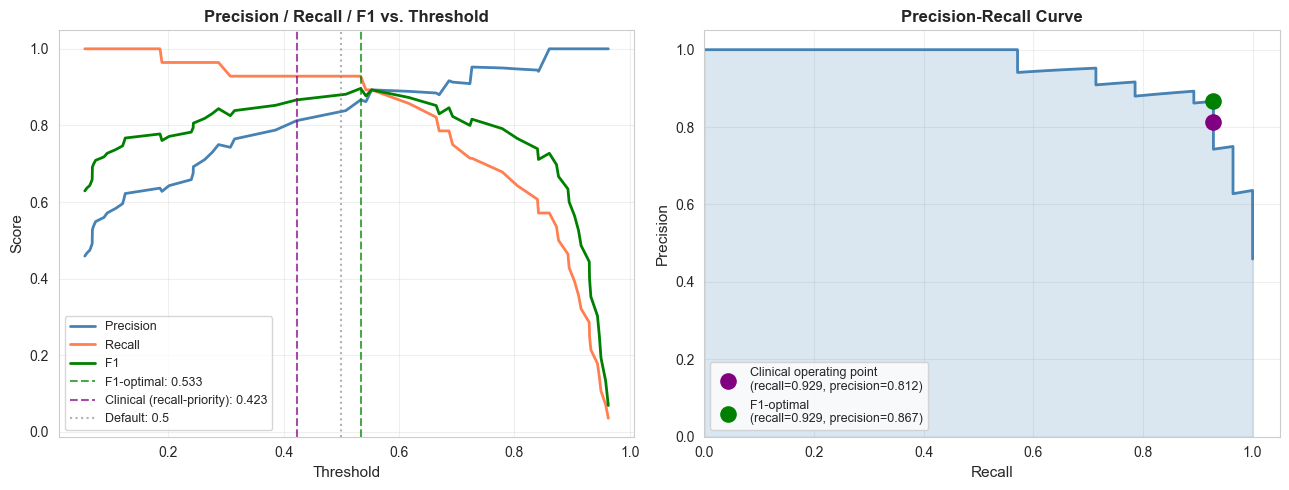

In [14]:
# Cell 12 — Find optimal threshold for clinical use (corrected)
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)

f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
f1_scores_truncated = f1_scores[:-1]
best_idx = np.argmax(f1_scores_truncated)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores_truncated[best_idx]

# Clinical threshold (RECALL-PRIORITY): the LOWEST threshold where precision >= 0.80
# precision_recall_curve returns arrays sorted from low-recall/high-precision to high-recall/low-precision.
# We want the FIRST (smallest threshold) point where precision is acceptable — maximizes recall.
acceptable_precision = 0.80
clinical_indices = np.where(precisions[:-1] >= acceptable_precision)[0]

if len(clinical_indices) > 0:
    # Pick the index with the highest recall while precision is still >= 0.80
    clinical_idx = clinical_indices[np.argmax(recalls[clinical_indices])]
    clinical_threshold = thresholds[clinical_idx]
    clinical_recall = recalls[clinical_idx]
    clinical_precision = precisions[clinical_idx]
else:
    clinical_idx = best_idx
    clinical_threshold = best_threshold
    clinical_recall = recalls[best_idx]
    clinical_precision = precisions[best_idx]

# Default threshold metrics (find closest to 0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
default_precision = precisions[default_idx]
default_recall = recalls[default_idx]

print("=" * 60)
print("THRESHOLD ANALYSIS (corrected)")
print("=" * 60)
print(f"\nDefault threshold (0.5):")
print(f"  Precision: {default_precision:.4f}")
print(f"  Recall:    {default_recall:.4f}")

print(f"\nF1-optimal threshold ({best_threshold:.4f}):")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  F1:        {best_f1:.4f}")

print(f"\nClinical threshold (max recall with precision >= 0.80): {clinical_threshold:.4f}")
print(f"  Precision: {clinical_precision:.4f}")
print(f"  Recall:    {clinical_recall:.4f}")

# Visualize
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', color='coral', linewidth=2)
plt.plot(thresholds, f1_scores_truncated, label='F1', color='green', linewidth=2)
plt.axvline(best_threshold, color='green', linestyle='--', alpha=0.7, label=f'F1-optimal: {best_threshold:.3f}')
plt.axvline(clinical_threshold, color='purple', linestyle='--', alpha=0.7, label=f'Clinical (recall-priority): {clinical_threshold:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='Default: 0.5')
plt.xlabel('Threshold', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Precision / Recall / F1 vs. Threshold', fontsize=12, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, color='steelblue', linewidth=2)
plt.fill_between(recalls, precisions, alpha=0.2, color='steelblue')
plt.scatter([clinical_recall], [clinical_precision], color='purple', s=120, zorder=5,
            label=f'Clinical operating point\n(recall={clinical_recall:.3f}, precision={clinical_precision:.3f})')
plt.scatter([recalls[best_idx]], [precisions[best_idx]], color='green', s=120, zorder=5,
            label=f'F1-optimal\n(recall={recalls[best_idx]:.3f}, precision={precisions[best_idx]:.3f})')
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curve', fontsize=12, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1.05])
plt.ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../reports/figures/threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
# Cell 13 — Save calibration artifacts (corrected metadata)
import json

calibration_summary = {
    'brier_raw': float(brier_raw),
    'brier_calibrated': float(brier_cal),
    'calibration_decision': 'use_raw_model',
    'reason': 'Platt scaling degraded Brier on this small dataset; raw model is well-calibrated enough.',
    'recommended_threshold_default': 0.5,
    'recommended_threshold_f1': float(best_threshold),
    'recommended_threshold_clinical': float(clinical_threshold),
    'clinical_threshold_precision': float(clinical_precision),
    'clinical_threshold_recall': float(clinical_recall),
    'clinical_threshold_rationale': 'Maximize recall (sensitivity) for screening, accepting more false alarms; precision constraint >= 0.80'
}

with open('../models/calibration_metadata.json', 'w') as f:
    json.dump(calibration_summary, f, indent=2)

print("Saved corrected calibration metadata:")
print(json.dumps(calibration_summary, indent=2))

Saved corrected calibration metadata:
{
  "brier_raw": 0.09222429990768433,
  "brier_calibrated": 0.10373897537295314,
  "calibration_decision": "use_raw_model",
  "reason": "Platt scaling degraded Brier on this small dataset; raw model is well-calibrated enough.",
  "recommended_threshold_default": 0.5,
  "recommended_threshold_f1": 0.5334317684173584,
  "recommended_threshold_clinical": 0.42262399196624756,
  "clinical_threshold_precision": 0.8125,
  "clinical_threshold_recall": 0.9285714285714286,
  "clinical_threshold_rationale": "Maximize recall (sensitivity) for screening, accepting more false alarms; precision constraint >= 0.80"
}
